In [2]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)

import nltk
from nltk.corpus import stopwords

#make them shut up please
warnings.filterwarnings("ignore")

# Dataset Description & Problem Statement

## Dataset

### Source
The dataset comes from the **U.S. Consumer Financial Protection Bureau (CFPB) Consumer Complaint Database**, a public-domain government open-data portal.

- **Homepage:** https://www.consumerfinance.gov/data-research/consumer-complaints/
- **Direct download:** https://files.consumerfinance.gov/ccdb/complaints.csv.zip
- **License:** Public domain (U.S. government work)

The full database contains millions of real consumer complaints filed against financial institutions. For this project, a balanced subset was extracted using a streaming sampler (`dataset_download.py`) to keep the working file manageable while preserving real-world complexity.

### Number of Records
- **Working dataset size:** 25,000 complaints
- **Records per class:** 5,000 (perfectly balanced as all things should be)
- **Sampling:** Random selection with `random_state=42` for reproducibility

A balanced subset was chosen so that accuracy and macro-F1 reflect actual classifier performance rather than majority-class bias.

### Features
The dataset combines **free text, categorical, and numeric** features

| Feature | Type | Role in Pipeline |
|---|---|---|
| `Consumer complaint narrative` | Free text | Vectorized via TF-IDF (word 1–2 grams + char 3–5 grams) |
| `State` | Categorical (~52 values) | One-hot encoded |
| `Submitted via` | Categorical (~6 values) | One-hot encoded |
| `Company response to consumer` | Categorical (~7 values) | One-hot encoded |
| `Timely response?` | Binary | One-hot encoded |
| `narrative_length` | Numeric (derived) | Standardized (StandardScaler) |
| `word_count` | Numeric (derived) | Standardized (StandardScaler) |

**Excluded from training:** `Sub-product` and `Issue` were kept in the CSV for exploratory analysis but excluded as features because they are tightly coupled with the target, including them would constitute label leakage where it effectively "cheats" predictions.

### Target Variable
The target is **`Product`** the financial product category a complaint pertains to. After normalizing duplicate CFPB labels (the agency renamed several categories in 2022 but both old and new names persist in the historical data), the task uses **5 classes**:

1. **Bank Account**
2. **Credit Card**
3. **Credit Reporting**
4. **Debt Collection**
5. **Mortgage**

This makes the task a **5-class multi-class classification problem**.

---


## Problem Statement

**What problem are we solving?**

The CFPB receives a constant flood of consumer complaints about financial products and services. Each complaint must be routed to the appropriate internal team (mortgage specialists, credit reporting analysts, debt collection investigators, etc.) for review and resolution. Manually triaging every incoming narrative is slow, expensive, and inconsistent across human reviewers.

**The goal of this project is to build a multi-class text classifier that automatically predicts the correct product category from a consumer's complaint narrative and accompanying metadata.** A reliable classifier would allow the CFPB (or any equivalent consumer-protection body) to:

- **Route complaints faster** to the correct specialist team without human pre-screening.
- **Reduce misrouting**, which delays consumer response times and clogs the wrong team's queue.
- **Surface trends** by product category in near real-time for regulatory monitoring.
- **Free human reviewers** to focus on edge cases and ambiguous complaints rather than obvious routing decisions.

The technical challenge is that complaint narratives are messy: they contain heavy PII redaction artifacts (`XXXX`, `XX/XX/XXXX`, `$XXXX`), informal language, misspellings, and significant overlap in vocabulary across categories (e.g., the word *"account"* appears constantly in Bank Account, Credit Card, and Credit Reporting complaints alike). The model must learn to distinguish categories from subtle linguistic patterns combined with structured metadata signals — exactly the kind of mixed-feature problem that real-world ML systems face.

In [3]:
#set up configs for the pipeline

INPUT_CSV = Path("cfpb_with_other_30k.csv")

#save outputs for easier documentation
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
TEST_SIZE = 0.20

TEXT_COL = "Consumer complaint narrative"
LABEL_COL = "Product"
CATEGORICAL_COLS = [
    "State",
    "Submitted via",
    "Company response to consumer",
    "Timely response?",
]

VAL_FRACTION_OF_TRAIN = 0.125  # 0.8 * 0.125 = 0.10 of total -> 70/10/20 split
OOD_TARGET_COVERAGE = 0.95
OOS_DISPLAY_LABEL = "Out of Scope"

In [4]:
#Hyperparameters were found through earlier experimentation via CV gridsearch. They are now hard-encoded here in order to save compute time.

SVM_C = 0.5
MLP_HIDDEN = (128, 64)
TFIDF_WORD_NGRAMS = (1, 2)
TFIDF_CHAR_NGRAMS = (3, 5)
TFIDF_MAX_FEATURES = 30_000 

In [5]:
#added typical phrase markers targeting the two persistent confusion pairs between classes in the hopes of getting better discrimination per class
#observed in the confusion matrix:
#   (a) Debt Collection  <->  Credit Reporting
#   (b) Credit Card      <->  Bank Account
#
#each phrase is matched against the cleaned narrative as a whole-word regex.
#the output is a small dense binary matrix (1 column per phrase) that gets
#hstacked alongside the TF-IDF matrices. Cheap, interpretable, and directly
#attacks the off-diagonal cells in the confusion matrix.

PAIR_DISCRIMINATOR_PHRASES = {
    #use regex to find close matches and we add them as a binary col in the sparse feature matrix
    #\b just forces it to match start and ends, | gives potential values for example agenc(y}ies) allows it to either take agency or agencies
    # adding ? at the end of a group makes it optional
    
    #debt Collection markers
    "debt_collection_agency":   r"\bcollection agenc(y|ies)\b",
    "debt_calling_me":          r"\b(calling|called|calls) me\b",
    "debt_validation_letter":   r"\bvalidation letter\b",
    "debt_fdcpa":               r"\bfdcpa\b",
    "debt_original_creditor":   r"\boriginal creditor\b",
    "debt_settle":              r"\bsettle (the |this )?debt\b",
    "debt_third_party":         r"\bthird[- ]party\b",
    "debt_collector":           r"\b(debt )?collector(s)?\b",

    #credit Reporting markers
    "cr_dispute":               r"\bdispute(d|s|ing)?\b",
    "cr_inaccurate":            r"\b(inaccurate|incorrect|erroneous)\b",
    "cr_equifax":               r"\bequifax\b",
    "cr_experian":              r"\bexperian\b",
    "cr_transunion":            r"\btrans ?union\b",
    "cr_credit_bureau":         r"\bcredit bureau(s)?\b",
    "cr_reinvestigation":       r"\breinvestigat(e|ion|ing)\b",
    "cr_fcra":                  r"\bfcra\b",
    "cr_credit_report":         r"\bcredit report(ing|s)?\b",

    #credit card markers
    "cc_apr":                   r"\bapr\b",
    "cc_interest_rate":         r"\binterest rate\b",
    "cc_cash_advance":          r"\bcash advance\b",
    "cc_minimum_payment":       r"\bminimum payment\b",
    "cc_balance_transfer":      r"\bbalance transfer\b",
    "cc_credit_limit":          r"\bcredit limit\b",
    "cc_rewards":               r"\b(rewards|points|cashback)\b",

    #bank Account markers
    "ba_checking":              r"\bchecking (account)?\b",
    "ba_savings":               r"\bsavings (account)?\b",
    "ba_deposit":               r"\b(deposit|deposited|depositing)\b",
    "ba_overdraft":             r"\boverdraft( fee)?\b",
    "ba_atm":                   r"\batm\b",
    "ba_wire_transfer":         r"\bwire transfer\b",
    "ba_direct_deposit":        r"\bdirect deposit\b",
}

In [6]:
def build_pair_discriminator_features(narratives):
    
    #build a sparse binary matrix of phrase-presence features.
    #Parameters
    #narratives : pd.Series of cleaned narrative strings
    #Returns
    #X_pair : scipy.sparse.csr_matrix, shape (n_docs, n_phrases)
    #feature_names : list[str]
    

    #his essentially creates a binary matrix that indicates if the presence
    #of these phrases exist within the text
    #should be much stronger indicators for our confused classes.
    
    feature_names = list(PAIR_DISCRIMINATOR_PHRASES.keys())
    compiled = [re.compile(pat, flags=re.IGNORECASE)
                for pat in PAIR_DISCRIMINATOR_PHRASES.values()]

    n_docs = len(narratives)
    n_feats = len(feature_names)
    M = np.zeros((n_docs, n_feats), dtype=np.float32)

    narr_list = narratives.tolist()
    for i, text in enumerate(narr_list):
        if not text:
            continue
        for j, regex in enumerate(compiled):
            if regex.search(text):
                M[i, j] = 1.0

    return csr_matrix(M), feature_names

## Text Cleaning 

Raw CFPB complaint narratives are noisy in ways that would actively mislead a TF-IDF model if left untouched. The `clean_text()` function applies four transformations in a deliberate order, each addressing a specific failure mode.

### 1. Lowercasing
All text is converted to lowercase first so that `"Mortgage"`, `"mortgage"`, and `"MORTGAGE"` collapse to a single token. Without this step, TF-IDF treats them as three independent features, fragmenting signal and inflating the vocabulary unnecessarily.

### 2. PII Pattern Scrubbing
The CFPB redacts personally identifiable information **before publishing** complaints, replacing names, dates, dollar amounts, and account numbers with placeholder tokens like `XXXX`, `XX/XX/XXXX`, and `$XXXX`. These artifacts are extremely frequent ,they appear in nearly every narrative, and if left in the corpus they would:

- **Dominate the TF-IDF vocabulary**, crowding out genuinely informative words.
- **Become spurious top features**, making the model appear to "learn" patterns that are really just redaction frequency.
- **Mislead interpretability outputs** like `top_features_per_class.txt`, where `xxxx` would otherwise rank near the top of every class.

The `PII_PATTERNS` list targets each redaction shape explicitly:

| Pattern | Matches | Example |
|---|---|---|
| `x{2,}` | Two or more consecutive `x`s | `XXXX`, `xxxxxx` |
| `x+/x+/x+` | Redacted date triplets | `XX/XX/XXXX` |
| `\{?\$[\d,.xX]+\}?` | Redacted or real dollar amounts | `$XXXX`, `{$1,234.00}` |
| `\d{1,2}/\d{1,2}/\d{2,4}` | Real dates that escaped redaction | `3/15/2023` |
| `\d{3}-\d{2}-\d{4}` | SSN-shaped strings | `123-45-6789` |
| `\b\d{9,}\b` | Long digit runs (account numbers) | `4532019283746` |
| `http\S+` | URLs | `https://example.com/...` |
| `\S+@\S+` | Email addresses | `user@domain.com` |

### 3. Non-Alphabetic Character Removal
After PII scrubbing, any remaining punctuation, digits, or symbols are stripped (`NON_ALPHA_RE`). This keeps the vocabulary focused on actual words. Numbers and punctuation rarely carry product-category signal in this corpus.

### 4. Whitespace Normalization
The previous substitutions leave behind runs of spaces where text used to be. `MULTI_SPACE_RE` collapses any sequence of whitespace into a single space, and `.strip()` trims the edges.

In [7]:
#as statedm complaints typically have a lot of useless noise since they have been redactd, we need to remove as many as we can
PII_PATTERNS = [
    r"x{2,}", r"x+/x+/x+", r"\{?\$[\d,.xX]+\}?", r"\d{1,2}/\d{1,2}/\d{2,4}",
    r"\d{3}-\d{2}-\d{4}", r"\b\d{9,}\b", r"http\S+", r"\S+@\S+",
]

# compiled big boy optional regex, ignore cases ofc
COMBINED_PII_RE = re.compile("|".join(PII_PATTERNS), flags=re.IGNORECASE)

#mask to remove anything that isnt an alphanumeric
NON_ALPHA_RE = re.compile(r"[^a-z\s]")
#remove any multi-space chars
MULTI_SPACE_RE = re.compile(r"\s+")

#small helper to ensure that we do have nltk stopwords available for our tf-idf
def ensure_nltk():
    try:
        stopwords.words("english")
    except LookupError:
        nltk.download("stopwords", quiet=True)


#passes a string through all of our mask filters
def clean_text(s: str):
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = COMBINED_PII_RE.sub(" ", s)
    s = NON_ALPHA_RE.sub(" ", s)
    s = MULTI_SPACE_RE.sub(" ", s).strip()
    return s

In [8]:
#loads  the dataset and passes it through the clean_text function
def load_and_preprocess():

    #load the dataset
    df = pd.read_csv(INPUT_CSV)
    
    #dropNAs as our handling, there are no valid imputations available for text data
    df = df.dropna(subset=[TEXT_COL, LABEL_COL])
    df = df[df[TEXT_COL].str.strip() != ""]
    for col in CATEGORICAL_COLS:
        df[col] = df[col].fillna("Unknown").astype(str).str.strip()

    #apply clean to all narrative_length and add len as a col
    df["narrative_clean"] = df[TEXT_COL].map(clean_text)
    df["narrative_length"] = df[TEXT_COL].str.len().fillna(0).astype(int)
    df["word_count"] = df["narrative_clean"].str.split().map(len)

    #remove old incdices, pd quirk
    df = df.reset_index(drop=True)

    #print fndings
    print(f"Shape: {df.shape} | Classes: {df[LABEL_COL].nunique()}")
    print(f"Class distribution:\n{df[LABEL_COL].value_counts().to_string()}")
    return df


df = load_and_preprocess()

Shape: (30000, 13) | Classes: 6
Class distribution:
Product
Credit Reporting    5000
Mortgage            5000
Other               5000
Debt Collection     5000
Credit Card         5000
Bank Account        5000


## Dealing with Data Leakage

We need to drop categorical features dominated by a single value above this threshold.
two reasons a dominated column is bad:
1. No signal: if 98% of rows share one value, the column gives the model essentially zero discriminative information.
2. Temporal leakage: fields like 'Company response to consumer' are populated *after* triage, so using them as features cheats. The dominance audit catches this incidentally because such fields tend to have one overwhelmingly common resolution outcome.

In [9]:
# drop categorical features dominated by a single value above this threshold.
#  two reasons a dominated column is bad:
#   1. No signal: if 98% of rows share one value, the column gives the model
#      essentially zero discriminative information.
#   2. Temporal leakage: fields like 'Company response to consumer' are
#      populated *after* triage, so using them as features cheats. The
#      dominance audit catches this incidentally because such fields tend
#      to have one overwhelmingly common resolution outcome.
DOMINANCE_THRESHOLD = 0.50

def audit_categorical_dominance(frame, cols, threshold):
    keep, drop = [], []
    print(f"Categorical dominance audit (drop if any single value covers >= {threshold:.0%}):\n")
    for col in cols:
        counts = frame[col].value_counts(normalize=True)
        top_val, top_pct = counts.index[0], counts.iloc[0]
        verdict = "DROP" if top_pct >= threshold else "KEEP"
        (drop if verdict == "DROP" else keep).append(col)
        print(f"  [{verdict}]  {col:<32s}  '{top_val}' covers {top_pct:.1%}")
    print()
    return keep, drop

CATEGORICAL_COLS, DROPPED_COLS = audit_categorical_dominance(
    df, CATEGORICAL_COLS, DOMINANCE_THRESHOLD
)
print(f"Surviving categorical features ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}")
print(f"Dropped ({len(DROPPED_COLS)}): {DROPPED_COLS}")

Categorical dominance audit (drop if any single value covers >= 50%):

  [KEEP]  State                             'CA' covers 12.5%
  [DROP]  Submitted via                     'Web' covers 100.0%
  [DROP]  Company response to consumer      'Closed with explanation' covers 77.6%
  [DROP]  Timely response?                  'Yes' covers 97.8%

Surviving categorical features (1): ['State']
Dropped (3): ['Submitted via', 'Company response to consumer', 'Timely response?']


## Text Preprocessing: Tokenization, Stopword Removal, Vectorization and Transformation

All three standard text-preprocessing steps are handled inside the `TfidfVectorizer` calls in `build_features()`. scikit-learn folds them into a single fit/transform pass rather than requiring three separate stages.

### Tokenization
Two vectorizers run in parallel, each with a different tokenization strategy:

- **Word vectorizer** (`analyzer="word"`) splits the cleaned narrative on whitespace into word tokens, then forms **1-grams and 2-grams** (`ngram_range=(1, 2)`). Bigrams capture short phrases like *"credit report"* or *"late payment"* that carry more signal than either word alone.
- **Character vectorizer** (`analyzer="char_wb"`) tokenizes into **3-to-5 character n-grams** within word boundaries. This catches abbreviations, misspellings, and morphological variants (e.g., *"mortg"*, *"ortgag"*) that pure word tokenization would miss.

Running both gives the model lexical signal (whole words and phrases) **and** sub-lexical signal (character patterns) without committing to one or the other.

### Stopword Removal
Applied only to the **word vectorizer** via `stop_words=english_stops`, using NLTK's English stopword list. Common function words (*the*, *and*, *of*, *was*) are dropped before TF-IDF weights are computed, so the vocabulary stays focused on content-bearing terms.

Stopwords are **not** removed from the character vectorizer, character n-grams of stopwords are usually too short or too generic to dominate, and removing them would distort the boundary patterns `char_wb` is designed to capture.

Two additional vocabulary filters tighten this further:
- `min_df=3` — drops terms appearing in fewer than 3 documents (rare noise).
- `max_df=0.9` — drops terms appearing in more than 90% of documents (effectively domain-specific stopwords like *"complaint"* or *"company"*).

### Vectorization
**TF-IDF** was chosen over plain `CountVectorizer` because raw counts overweight long narratives: a 2,000-word complaint mentioning *"mortgage"* 30 times shouldn't dominate over a focused 200-word complaint mentioning it 5 times. TF-IDF normalizes for document length and downweights terms that appear everywhere.

Three settings refine the weighting:
- `sublinear_tf=True` — applies `1 + log(tf)` instead of raw term frequency, preventing high-frequency terms within a single document from drowning out everything else.
- `max_features=30_000` — caps each vectorizer's vocabulary at the top 30k terms by document frequency, balancing expressiveness against memory and training time.
- IDF weighting (default) — scales each term by how rare it is across the corpus, so genuinely discriminative words get higher weight than common ones.

### Final Feature Matrix
The two TF-IDF outputs are then `hstack`ed together with the one-hot categorical and standardized numeric features into a single sparse matrix `X_combined` (shape ≈ 25,000 × 60,000+). This is what the SVM and MLP train on; Naive Bayes uses only the text portion (`X_text_only`) since it requires non-negative inputs.

In [10]:
#Perform Feature Engineering Tasks
def build_features(df):
    #sklearn expects a list so we need to mutate it
    english_stops = list(stopwords.words("english"))

    # Word TF-IDF: 1-2 grams
    tfidf_word = TfidfVectorizer(
        analyzer="word",
        ngram_range=TFIDF_WORD_NGRAMS,
        min_df=3,
        max_df=0.9,
        max_features=TFIDF_MAX_FEATURES,
        stop_words=english_stops,
        sublinear_tf=True,
    )
    X_word = tfidf_word.fit_transform(df["narrative_clean"])
    print(f"Word TF-IDF:{X_word.shape}")

    #Char TF-IDF: 3-5 grams (catches abbreviations, misspellings, residual artifacts)
    tfidf_char = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=TFIDF_CHAR_NGRAMS,
        min_df=3,
        max_df=0.9,
        max_features=TFIDF_MAX_FEATURES,
        sublinear_tf=True,
    )

    X_char = tfidf_char.fit_transform(df["narrative_clean"])
    print(f"Char TF-IDF:{X_char.shape}")

    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    X_cat = ohe.fit_transform(df[CATEGORICAL_COLS])
    print(f"Categorical:{X_cat.shape}")

    scaler = StandardScaler()
    X_num = csr_matrix(scaler.fit_transform(df[["narrative_length", "word_count"]]))
    print(f"Numeric:{X_num.shape}")

    X_pair, pair_feat_names = build_pair_discriminator_features(df["narrative_clean"])
    print(f"Pair-discriminator: {X_pair.shape}  ({len(pair_feat_names)} phrases)")

    #hstack allows us to stack up our sparce matrices into one big matrix we can use for training
    X_combined = hstack([X_word, X_char, X_cat, X_num, X_pair]).tocsr()
    X_text_only = hstack([X_word, X_char]).tocsr()  # for NB (needs >=0)
    print(f"COMBINED:{X_combined.shape}\n")

    labels = sorted(df[LABEL_COL].unique().tolist())
    y = df[LABEL_COL].map({lbl: i for i, lbl in enumerate(labels)}).values

    #return a dict for easier all in one access.
    return {
        "X_combined": X_combined,
        "X_text_only": X_text_only,
        "y": y,
        "labels": labels,

        #mainly here for input inferencing, we need to store the same processes
        "tfidf_word": tfidf_word,
        "tfidf_char": tfidf_char,
        "ohe": ohe,
        "scaler": scaler,
    }



data = build_features(df)

Word TF-IDF:(30000, 30000)
Char TF-IDF:(30000, 30000)
Categorical:(30000, 59)
Numeric:(30000, 2)
Pair-discriminator: (30000, 31)  (31 phrases)
COMBINED:(30000, 60092)



## Model Evaluation Metrics

We report four metrics per model, each chosen because it answers a question the others can't:

- **Accuracy** — the headline overall-correctness number; meaningful here because the test set is perfectly balanced (1,000 per class), so it isn't skewed by majority-class dominance.
- **Macro Precision** — averages per-class precision equally, telling us whether predictions for each product category are trustworthy without letting a strong class mask a weak one.
- **Macro Recall** — averages per-class recall equally, revealing whether any single category is being systematically under-predicted (e.g., Bank Account complaints getting absorbed into Credit Card).
- **Macro F1** — the harmonic mean of precision and recall per class, used as the single tiebreaker metric when ranking the three models.
- **Confusion Matrix** — shows exactly *which* class pairs the model confuses, surfacing structural errors (e.g., Credit Reporting ↔ Debt Collection overlap) that scalar metrics hide.

In [11]:
#all in one model evaluator
def evaluate(name, model, X_test, y_test, labels):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    #all in one func, much easier
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    report = classification_report(
        y_test, y_pred, target_names=labels, zero_division=0, digits=4
    )

    cm = confusion_matrix(y_test, y_pred)

    #again, store everything in a dict for easier access
    return {
        "name": name, "accuracy": acc, "macro_precision": prec,
        "macro_recall": rec, "macro_f1": f1, "report": report,
        "confusion_matrix": cm, "y_pred": y_pred, "model": model,
    }

## Model Selection & Hyperparameter Rationale

The three classifiers were chosen to span the major paradigms of multi-class classification  **probabilistic**, **max-margin**, and **connectionist**  so the comparison reflects genuinely different modeling philosophies rather than minor variants of the same approach.

**note** We used modified versions of the original algorithms suggested, functionally they remain the same but the models used we're made to support the dataset better.

### 1. Multinomial Naive Bayes (text only)
The canonical baseline for text classification.  Multinomial NB is designed for exactly this case: non-negative count-like features (TF-IDF qualifies) over a fixed vocabulary, making it the standard pairing with text vectorizers.

- **`alpha=0.1`** — Laplace smoothing for unseen word/class combinations. Default `1.0` was too aggressive on high-dimensional TF-IDF features and underweighted real signal; `0.1` was the sweet spot found in earlier iterations.
- **Text features only** — `MultinomialNB` requires non-negative inputs, so the standardized numeric features (which contain negatives) can't be included. This is also why NB serves as a useful *contrast* model: any gap between NB and the other two quantifies what the tabular features add (since it does not use it in training).

### 2. Linear SVM (LinearSVC, combined features)
The industry standard for high-dimensional sparse text classification. Trains in seconds on 60k+ features and consistently performs at or near the top. **`LinearSVC`** uses a specialized linear solver (liblinear/dual coordinate descent) that scales linearly with samples and exploits sparsity natively, trains in seconds instead of hours, with equal or better accuracy on this kind of data. For TF-IDF text classification, going non-linear is almost always wasted compute.


- **`C=0.5`** — regularization strength found via 3-fold CV grid search over `{0.2, 0.3, 0.5, 0.7, 1.0, 2.0}`. Smaller values overregularized; larger values overfit.
- **`class_weight="balanced"`** — gives a small consistent gain even on perfectly balanced data by reweighting confusable class pairs during fitting.
- **`dual="auto"`** — lets scikit-learn pick the optimal solver (primal vs dual) based on the n_samples-to-n_features ratio, avoiding deprecation warnings.
- **`max_iter=3000`** — generous ceiling so convergence is never the bottleneck; actual runs converge well before this.

### 3. Neural Network / MLP (combined features)
Demonstrates the modern connectionist approach and tests whether non-linear interactions among features add anything beyond what the linear SVM captures.

- **`hidden_layer_sizes=(128, 64)`** — two hidden layers of moderate width. Larger architectures like `(256, 128)` were tested and underperformed, suggesting the dataset isn't large enough to support more capacity without overfitting.
- **`activation="relu"` + `solver="adam"`** — standard modern defaults; ReLU avoids vanishing gradients, Adam adapts learning rates per parameter.
- **`alpha=1e-4`** — light L2 regularization to keep weights bounded.
- **`batch_size=128`** — small enough for stable gradient estimates on sparse input, large enough to keep training fast.
- **`max_iter=40` + `early_stopping=True` + `validation_fraction=0.1` + `n_iter_no_change=5`** early stopping on a held-out 10% slice typically halts training around iteration 15–25, which prevents overfitting and avoids burning compute on diminishing returns.
- **Raw sparse input (no SVD)** — TruncatedSVD dimensionality reduction was tested and dropped MLP accuracy by ~4 points; the network performs better when given the full sparse feature matrix directly.

## TAU

A normal classifier is forced to pick one of its known classes for every input, even when the input is gibberish or on a topic it was never trained on. We want an "I don't know" button so the model can route weird inputs to **Out of Scope** instead of returning a confident wrong answer. That's where τ comes in.

# How it works
For each prediction, we compute a confidence score in [0, 1] (how sure the model is about its top-class pick). Then:

- confidence ≥ τ → trust the prediction (**accept**)
- confidence < τ → route to "Out of Scope" (**reject**)

τ is calibrated on the validation set so we keep ~95% of *correctly-classified* val samples. In other words: we're willing to wrongly reject ~5% of correct predictions in exchange for catching the genuinely uncertain ones.

# What it means for metrics
Every test row ends up either **accepted** (confidence ≥ τ) or **rejected** (confidence < τ, displayed as "Out of Scope"). Our metrics now describe each bucket separately.

| Metric | Plain English |
|---|---|
| **Raw accuracy** | Correct / all test rows. Same as before. |
| **Coverage** | Accepted / all test rows. *"What fraction did we even commit on?"* |
| **Acc on accepted** | Correct / accepted. *"Of the ones we committed on, how often right?"* |
| **Per-class coverage** | Coverage by true class. Shows which classes the model is sure about. |

**Why acc on accepted is usually higher than raw accuracy:** we threw out the rows the model was unsure about, which is where most mistakes lived. The rows we kept are easier on average, so we get more of them right. **The gap = the value the rejection layer adds.**

**Per-class coverage** tells you *where* the uncertainty lives. Expect "Other" to have the lowest coverage; it's a fuzzy mix of 7 sub-topics, so the model is genuinely less sure when picking it. 

**The trade:** you spend a bit of coverage (availability) to buy reliability (accuracy on what you commit to). In real use that's almost always worth it; confidently wrong is worse than admitting uncertainty.

In [12]:
#a normal classifier is typically forced to pick one of the classes for any inoput, even if the input 
#clearly does not live in any of those categories
#we need to have some way for the model to be able to say "I Dont know" and make it useful.

#the plan:
#for each pred, we compute some confidence score, how sure the model is (supposed to be easy with predict_proba but some models work a little different)
#pick some threshold tau where a validation is set, preds beyond that are accepted, else model does not know
#upon testing, apply tau and report what fraction of test are accepted and how accurate that acceptances acctuyally were

def get_confidence_scores(model, X):

    #for each row within X, we return one num between 0 and 1, representing model confidence


    #classic, lovely, easy. for MLP and NB
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X).max(axis=1)
    
    
    #SVM is annoying. SVM does not have a probability
    #decision_function, their exposed "decider" returns a signed distance from a decision boundary
    #bigger = confident, but its not a probability.
    #as such we need to do some goofy math
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        #if dim is 1, we need to transform it to 2d (standard edge case check)
        if scores.ndim == 1:
            #stack the columns
            scores = np.column_stack([-scores, scores])
        
        #we can convert raw scores into probs via softmax
        # softmax(s_i) = exp(s_i) / sum_j exp(s_j)

        # the "subtract the max first" trick is purely for numerical
        # stability (prevents overflow when scores are large; result is
        # mathematically identical).        
        scores_shifted = scores - scores.max(axis=1, keepdims=True)
        exp_s = np.exp(scores_shifted)
        probs = exp_s / exp_s.sum(axis=1, keepdims=True)

        #do note this softmax isnt actually the "true" calibrated probability, as the real math gets abstracted from softmax
        #it does preseve something important, order.
        #we only really care that high score = confident, low score = not confident, only thing tau needs
        return probs.max(axis=1)
    
    #edge case check, again.
    raise ValueError(f"Model {type(model).__name__} has no confidence interface")



def calibrate_threshold(model, X_val, y_val, target_coverage=OOD_TARGET_COVERAGE):
    #choose a tau such that correctly classified OUT OF SCOPE targets reach this threshold of accuracy.
    #typically 95%, meaning it searches for this tau that gives us 95% correctly segregated to unknown.
    conf = get_confidence_scores(model, X_val)
    preds = model.predict(X_val)
    correct = preds == y_val
    if correct.sum() == 0:
        return 0.0
    
    # tau= the (1 - target_coverage) quantile of correct-prediction
    # confidences. Example: target_coverage=0.95 -> tau = 5th percentile.
    # this means 95% of correct val predictions sit at or above tau, so the
    # rule "accept iff confidence >= tau" keeps them. The 5% at the bottom
    # are the "borderline correct" calls we're choosing to also reject
    # the price we pay for catching the true OOS cases.
    return float(np.quantile(conf[correct], 1 - target_coverage))


def evaluate_with_rejection(model, X_test, y_test, tau, labels):
    #an eval function that utilizes our tau as the test
    
    #run model on test set
    conf = get_confidence_scores(model, X_test)
    preds = model.predict(X_test)
    
    #set the rejection rule, bool array
    accepted = conf >= tau


    n = len(y_test) 
    n_acc = int(accepted.sum())  #how many are accepted
    coverage = n_acc / n if n else 0.0 #fraction of accepted

    #amongst the accepted ones, what portion were actually properly classified
    #if we acceptt none, this is undefined so set to 0
    acc_on_acc = float((preds[accepted] == y_test[accepted]).mean()) if n_acc else 0.0


    #per class coverage
    #for each  true class label, what fraction of its test rows did we accept
    #if one class has low coverage, model is uncertain about it
    #we accept the fact that other will have lower coverage, as it is a mix of multiple smaller classes from the bigger dataset
    per_class = {}
    for ci, cls in enumerate(labels):
        mask = y_test == ci
        if mask.sum() == 0:
            continue
        per_class[cls] = {
            "coverage": float(accepted[mask].mean()),
            "n": int(mask.sum()),
        }
    
    #parse results cleanly in a dict <3
    return {
        "tau": tau, "coverage": coverage, "rejection_rate": 1 - coverage,
        "accuracy_on_accepted": acc_on_acc,
        "n_accepted": n_acc, "n_total": n,
        "per_class_coverage": per_class,
        "test_conf": conf, "test_pred": preds, "y_test": y_test,
    }

In [13]:
#helper function for train

def train_all(data):

    #split 2 datasets
    X_comb, X_text = data["X_combined"], data["X_text_only"]

    #y is the encoded labels, label is here for interpretability later on.
    y, labels = data["y"], data["labels"]

    #stratified 3-way split: 70% train / 10% val / 20% test
    #val is used solely to calibrate the OOD rejection threshold tau
    #without leaking train data into threshold calibration
    idx_all = np.arange(len(y))
    idx_trainval, idx_test = train_test_split(
        idx_all, test_size=TEST_SIZE,
        random_state=RANDOM_SEED, stratify=y,
    )
    idx_train, idx_val = train_test_split(
        idx_trainval, test_size=VAL_FRACTION_OF_TRAIN,
        random_state=RANDOM_SEED, stratify=y[idx_trainval],
    )

    #create the datasets
    Xc_tr, Xc_va, Xc_te = X_comb[idx_train], X_comb[idx_val], X_comb[idx_test]
    Xt_tr, Xt_va, Xt_te = X_text[idx_train], X_text[idx_val], X_text[idx_test]
    y_tr, y_va, y_te = y[idx_train], y[idx_val], y[idx_test]

    print(f"SPLIT: {len(y_tr):,} train / {len(y_va):,} val / {len(y_te):,} test")

    results = []

    #inner helper: calibrate tau on val, evaluate rejection on test, attach to result dict
    def _attach_rejection(result, model, X_va, X_te):
        tau = calibrate_threshold(model, X_va, y_va)
        result["tau"] = tau
        result["rejection"] = evaluate_with_rejection(model, X_te, y_te, tau, labels)
        rej = result["rejection"]
        print(f"    tau={tau:.4f}  coverage={rej['coverage']:.3f}  "
              f"acc(accepted)={rej['accuracy_on_accepted']:.4f}")

    #Multinomial Naive Bayes (text only needs non-negative features)
    print("\n[1] Multinomial Naive Bayes (text only)...")
    nb = MultinomialNB(alpha=0.1)
    nb.fit(Xt_tr, y_tr)
    r = evaluate("Naive Bayes", nb, Xt_te, y_te, labels)
    _attach_rejection(r, nb, Xt_va, Xt_te)
    results.append(r)

    # Linear SVM with locked hyperparameters
    print(f"\n[2] Linear SVM (combined, C={SVM_C}, balanced class weights)")
    svm = LinearSVC(
        C=SVM_C,
        class_weight="balanced",
        dual="auto",
        max_iter=3000,
        random_state=RANDOM_SEED,
    )
    svm.fit(Xc_tr, y_tr)
    r = evaluate("Linear SVM", svm, Xc_te, y_te, labels)
    _attach_rejection(r, svm, Xc_va, Xc_te)
    results.append(r)

    #  MLP, raw sparse combined features with early stopping
    print(f"\n[3] Neural Network / MLP (combined, hidden={MLP_HIDDEN})")
    mlp = MLPClassifier(
        hidden_layer_sizes=MLP_HIDDEN,
        activation="relu", solver="adam", alpha=1e-4,
        batch_size=128, learning_rate_init=1e-3,
        max_iter=40, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=5,
        random_state=RANDOM_SEED,
    )
    mlp.fit(Xc_tr, y_tr)
    print(f"MLP trained for {mlp.n_iter_} iterations")
    r = evaluate("Neural Network (MLP)", mlp, Xc_te, y_te, labels)
    _attach_rejection(r, mlp, Xc_va, Xc_te)
    results.append(r)

    return results, idx_test

results, idx_test = train_all(data)

SPLIT: 21,000 train / 3,000 val / 6,000 test

[1] Multinomial Naive Bayes (text only)...
    tau=0.6808  coverage=0.908  acc(accepted)=0.8302

[2] Linear SVM (combined, C=0.5, balanced class weights)
    tau=0.3160  coverage=0.897  acc(accepted)=0.8617

[3] Neural Network / MLP (combined, hidden=(128, 64))
MLP trained for 7 iterations
    tau=0.4961  coverage=0.904  acc(accepted)=0.8540


## Saving and Visalization Helpers

               Model  Accuracy  Macro Precision  Macro Recall  Macro F1    Tau  Coverage  Acc(Accepted)
          Linear SVM    0.8227           0.8223        0.8227    0.8216 0.3160    0.8967         0.8617
Neural Network (MLP)    0.8125           0.8175        0.8125    0.8140 0.4961    0.9043         0.8540
         Naive Bayes    0.7907           0.7907        0.7907    0.7872 0.6808    0.9082         0.8302

Naive Bayes
Accuracy:        0.7907
Macro Precision: 0.7907
Macro Recall:    0.7907
Macro F1:        0.7872

                  precision    recall  f1-score   support

    Bank Account     0.7724    0.8960    0.8296      1000
     Credit Card     0.7562    0.7600    0.7581      1000
Credit Reporting     0.7704    0.8220    0.7954      1000
 Debt Collection     0.7526    0.7150    0.7333      1000
        Mortgage     0.8857    0.9450    0.9144      1000
           Other     0.8069    0.6060    0.6922      1000

        accuracy                         0.7907      6000
       m

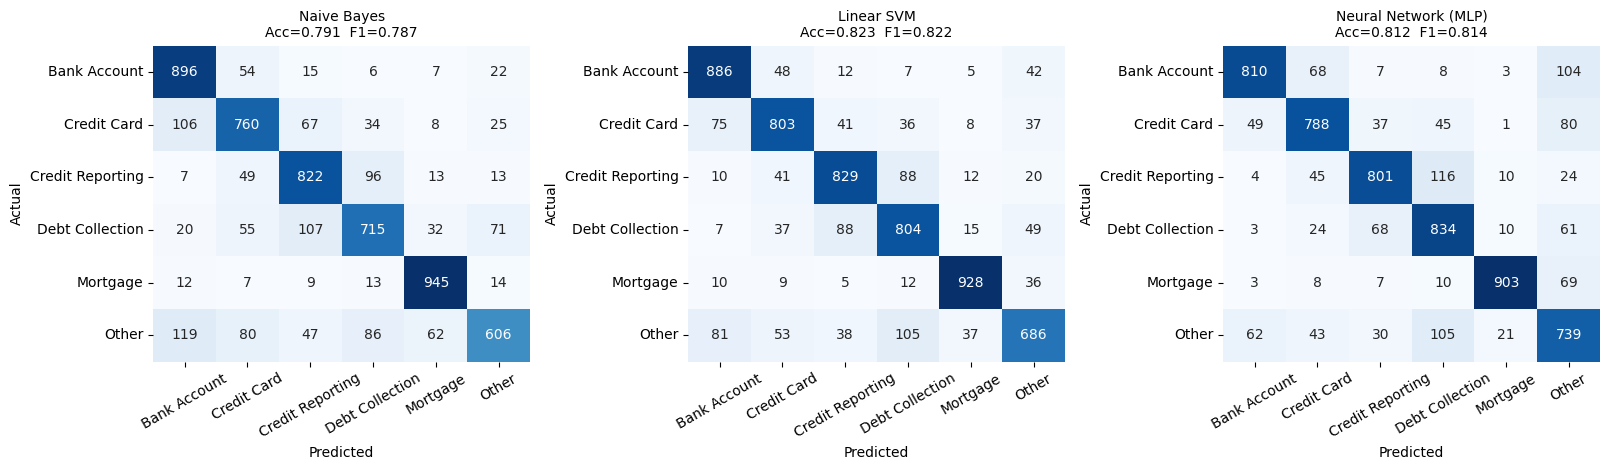


[saved] outputs\model_summary.csv
[saved] outputs\classification_reports.txt
[saved] outputs\confusion_matrices.png


In [14]:
def save_reports(results, labels):
    summary = pd.DataFrame([
        {
            "Model": r["name"],
            "Accuracy": round(r["accuracy"], 4),
            "Macro Precision": round(r["macro_precision"], 4),
            "Macro Recall": round(r["macro_recall"], 4),
            "Macro F1": round(r["macro_f1"], 4),
            #threshold layer metrics , surface tau and the selective-classification result
            "Tau": round(r["tau"], 4),
            "Coverage": round(r["rejection"]["coverage"], 4),
            "Acc(Accepted)": round(r["rejection"]["accuracy_on_accepted"], 4),
        }
        for r in results
    ]).sort_values("Accuracy", ascending=False).reset_index(drop=True)

    print(summary.to_string(index=False))
    summary.to_csv(OUT_DIR / "model_summary.csv", index=False)

    with open(OUT_DIR / "classification_reports.txt", "w", encoding="utf-8") as f:
        for r in results:
            f.write(f"\n{'=' * 70}\n{r['name']}\n{'=' * 70}\n")
            f.write(f"Accuracy:        {r['accuracy']:.4f}\n")
            f.write(f"Macro Precision: {r['macro_precision']:.4f}\n")
            f.write(f"Macro Recall:    {r['macro_recall']:.4f}\n")
            f.write(f"Macro F1:        {r['macro_f1']:.4f}\n\n")
            f.write(r["report"])
            f.write("\n")
    
    # Also print classification reports to notebook output
    for r in results:
        print(f"\n{'=' * 70}\n{r['name']}\n{'=' * 70}")
        print(f"Accuracy:        {r['accuracy']:.4f}")
        print(f"Macro Precision: {r['macro_precision']:.4f}")
        print(f"Macro Recall:    {r['macro_recall']:.4f}")
        print(f"Macro F1:        {r['macro_f1']:.4f}\n")
        print(r["report"])

    fig, axes = plt.subplots(1, len(results), figsize=(5.4 * len(results), 4.8))
    if len(results) == 1:
        axes = [axes]
    for ax, r in zip(axes, results):
        sns.heatmap(
            r["confusion_matrix"], annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=labels, yticklabels=labels, ax=ax,
        )
        ax.set_title(f"{r['name']}\nAcc={r['accuracy']:.3f}  F1={r['macro_f1']:.3f}",
                     fontsize=10)
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
        ax.tick_params(axis="x", rotation=30); ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "confusion_matrices.png", dpi=120, bbox_inches="tight")
    plt.show()  # display inline in the notebook
    plt.close()

    print(f"\n[saved] {OUT_DIR / 'model_summary.csv'}")
    print(f"[saved] {OUT_DIR / 'classification_reports.txt'}")
    print(f"[saved] {OUT_DIR / 'confusion_matrices.png'}")

save_reports(results, data["labels"])

Threshold-based Out-of-Scope Rejection
Calibration target: keep ~95% of correctly-
classified val samples (tau = the (1 - target) quantile of correct-
prediction confidences on the val set).

How to read this:
  - Coverage:        fraction of test rows whose top-class confidence
                     >= tau (i.e. accepted, not rejected as OOS).
  - Acc(Accepted):   accuracy on those accepted predictions.
                     Should be HIGHER than raw accuracy — that's the
                     selective-classification gain from rejection.
  - Per-class cov:   if a class has notably lower coverage, the model
                     is uncertain about it. The 'Other' class is
                     EXPECTED to have lower coverage (it's a mix of
                     7 sub-topics — an inherently fuzzy bucket).

[Naive Bayes]
  tau (threshold):         0.6808
  Raw accuracy:            0.7907
  Test coverage:           0.9082  (5,449/6,000)
  Rejection rate:          0.0918
  Accuracy on accepted:

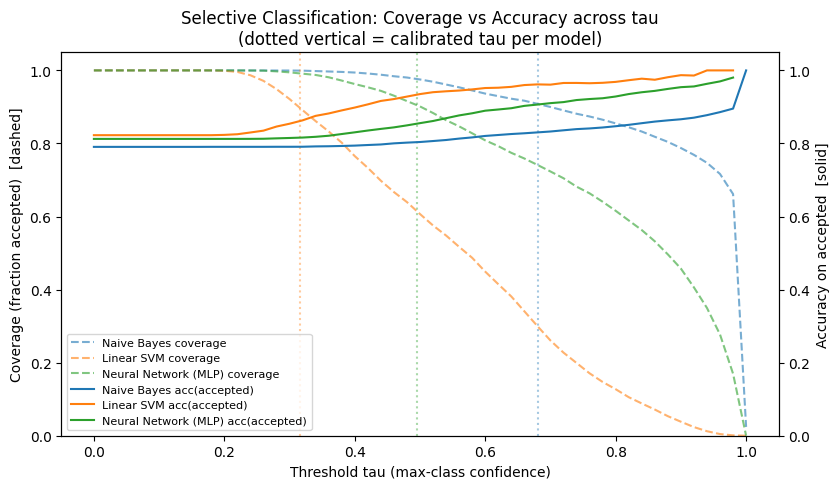

[saved] outputs\coverage_accuracy_curve.png


In [15]:
# two new artifacts that explain what the OOD rejection layer is doing.
# Run AFTER save_reports , they read r["rejection"] which train_all attached.

def save_threshold_report(results, labels):
    # per-model breakdown of tau, coverage, selective-classification gain,
    lines = [
        "Threshold-based Out-of-Scope Rejection",
        "=" * 70,
        f"Calibration target: keep ~{OOD_TARGET_COVERAGE:.0%} of correctly-",
        "classified val samples (tau = the (1 - target) quantile of correct-",
        "prediction confidences on the val set).",
        "",
        "How to read this:",
        "  - Coverage:        fraction of test rows whose top-class confidence",
        "                     >= tau (i.e. accepted, not rejected as OOS).",
        "  - Acc(Accepted):   accuracy on those accepted predictions.",
        "                     Should be HIGHER than raw accuracy — that's the",
        "                     selective-classification gain from rejection.",
        "  - Per-class cov:   if a class has notably lower coverage, the model",
        "                     is uncertain about it. The 'Other' class is",
        "                     EXPECTED to have lower coverage (it's a mix of",
        "                     7 sub-topics — an inherently fuzzy bucket).",
        "",
    ]
    for r in results:
        rej = r["rejection"]
        lines.append("=" * 70)
        lines.append(f"[{r['name']}]")
        lines.append("=" * 70)
        lines.append(f"  tau (threshold):         {r['tau']:.4f}")
        lines.append(f"  Raw accuracy:            {r['accuracy']:.4f}")
        lines.append(
            f"  Test coverage:           {rej['coverage']:.4f}  "
            f"({rej['n_accepted']:,}/{rej['n_total']:,})"
        )
        lines.append(f"  Rejection rate:          {rej['rejection_rate']:.4f}")
        lines.append(f"  Accuracy on accepted:    {rej['accuracy_on_accepted']:.4f}")
        delta = rej["accuracy_on_accepted"] - r["accuracy"]
        lines.append(f"  Selective-class. gain:   {delta:+.4f}")
        lines.append("  Per-class coverage on test:")
        for cls in labels:
            info = rej["per_class_coverage"].get(cls)
            if info is None:
                continue
            lines.append(
                f"    {cls:<25s}  {info['coverage']:.4f}  "
                f"({info['n']:,} test rows)"
            )
        lines.append("")

    text = "\n".join(lines)
    out = OUT_DIR / "threshold_report.txt"
    out.write_text(text, encoding="utf-8")
    print(text)
    print(f"[saved] {out}")


def save_coverage_curve(results):
    # coverage-vs-accuracy curve as tau sweeps from 0 to 1, per model.
    # visualizes the selective-classification tradeoff and lets the reader
    # see where the calibrated tau sits on the curve. If 95% coverage feels
    # too aggressive (or too lax) for a given deployment, this plot tells
    # you which tau corresponds to whatever coverage you actually want.
    fig, ax_cov = plt.subplots(figsize=(8.5, 5.0))
    ax_acc = ax_cov.twinx()

    taus = np.linspace(0.0, 1.0, 51)  # 0.00 to 1.00 in 0.02 steps
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, r in enumerate(results):
        rej = r["rejection"]
        conf = rej["test_conf"]
        preds = rej["test_pred"]
        y_te = rej["y_test"]
        c = color_cycle[i % len(color_cycle)]

        cov_curve, acc_curve = [], []
        for tau in taus:
            accepted = conf >= tau
            cov_curve.append(float(accepted.mean()))
            if accepted.any():
                acc_curve.append(float((preds[accepted] == y_te[accepted]).mean()))
            else:
                acc_curve.append(np.nan)

        ax_cov.plot(taus, cov_curve, "--", color=c, alpha=0.6,
                    label=f"{r['name']} coverage")
        ax_acc.plot(taus, acc_curve, "-", color=c,
                    label=f"{r['name']} acc(accepted)")
        ax_cov.axvline(r["tau"], color=c, linestyle=":", alpha=0.4)

    ax_cov.set_xlabel("Threshold tau (max-class confidence)")
    ax_cov.set_ylabel("Coverage (fraction accepted)  [dashed]")
    ax_acc.set_ylabel("Accuracy on accepted  [solid]")
    ax_cov.set_ylim(0, 1.05)
    ax_acc.set_ylim(0, 1.05)
    ax_cov.set_title(
        "Selective Classification: Coverage vs Accuracy across tau\n"
        "(dotted vertical = calibrated tau per model)"
    )
    h1, l1 = ax_cov.get_legend_handles_labels()
    h2, l2 = ax_acc.get_legend_handles_labels()
    ax_cov.legend(h1 + h2, l1 + l2, loc="lower left", fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "coverage_accuracy_curve.png",
                dpi=120, bbox_inches="tight")
    plt.show()  #render inline in the notebook
    plt.close()
    print(f"[saved] {OUT_DIR / 'coverage_accuracy_curve.png'}")


save_threshold_report(results, data["labels"])
save_coverage_curve(results)

**Interpretation.** The SVM has the most informative confidence signal, its softmax-of-decision-function spreads predictions across a wide range, so even small bumps in tau buy meaningful accuracy gains (orange solid climbs sharply, calibrated tau ≈ 0.32). Naive Bayes shows textbook overconfidence: its coverage stays flat near 1.0 until τ ≈ 0.85, meaning it assigns near-certain probability to almost every prediction regardless of whether it's right; the flat blue *acc-on-accepted* curve through most of the range confirms its confidence carries little signal, which is why the calibrator had to push NB's tau all the way up to ~0.68 just to filter the bottom 5%. MLP sits comfortably between the two smooth coverage decline, steady accuracy lift, calibrated tau ≈ 0.49. The practical takeaway: the rejection layer adds the most value on the SVM (cleanest separation between its dashed and solid curves), barely helps NB, and offers a respectable middle-of-the-road improvement on the MLP.

[saved] outputs\top_features_per_class.txt

Top 15 word features per class (from Linear SVM)

[Bank Account]
  debit card                      +1.438
  account                         +1.362
  card payment                    +1.355
  bank                            +1.237
  chime                           +1.128
  bill pay                        +1.118
  pnc                             +1.102
  debit                           +1.017
  pay back                        +0.969
  cd                              +0.968
  want back                       +0.907
  link account                    +0.873
  credit back                     +0.865
  deposit                         +0.864
  provisional                     +0.850

[Credit Card]
  card                            +3.319
  amex                            +1.269
  visa                            +1.211
  credit account                  +1.147
  back card                       +1.084
  keep sending                    +0.967
  card account 

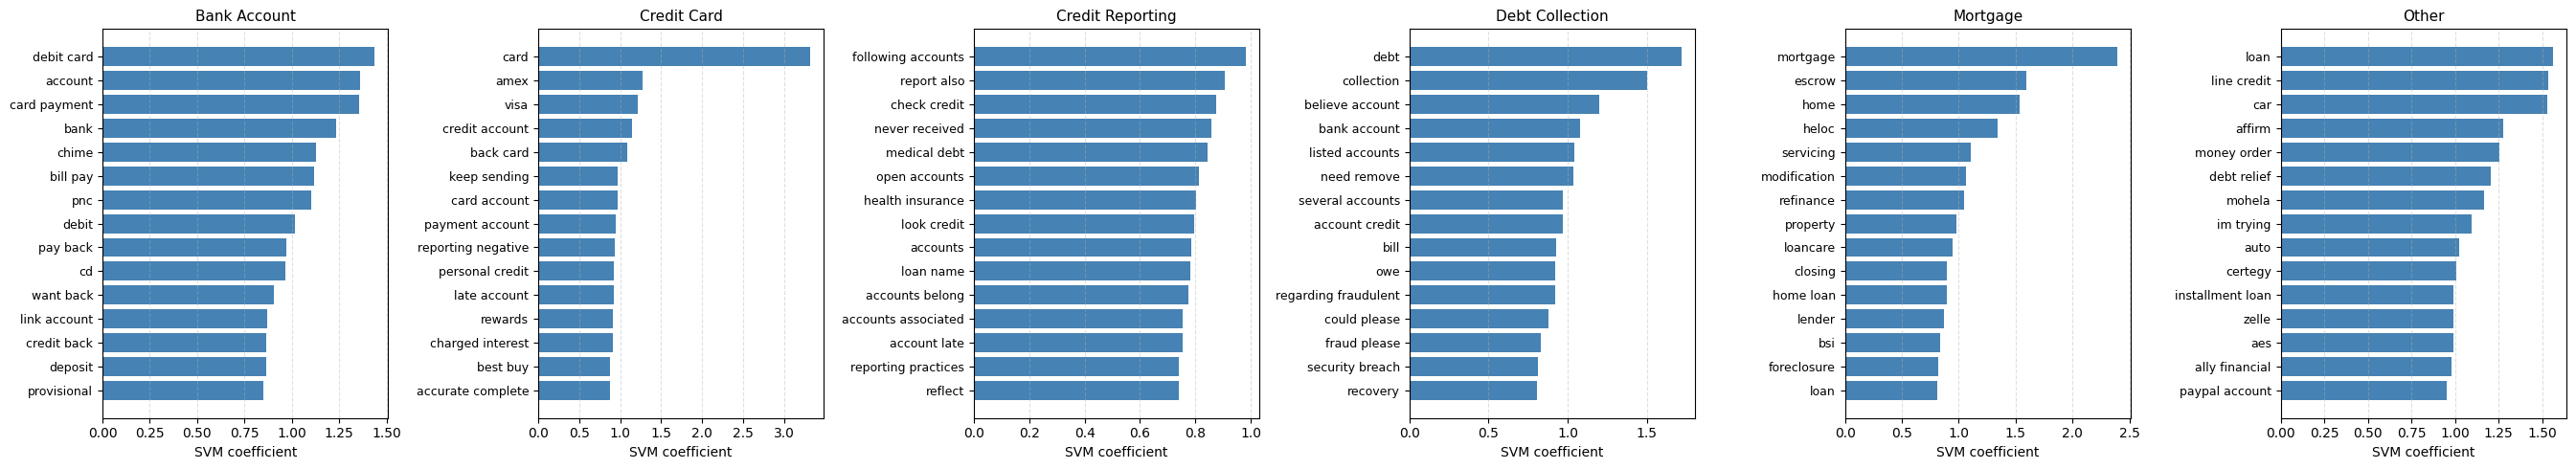

[saved] outputs\top_features_per_class.png


In [16]:
def save_top_features(results, data):
    
    #iterate over the results found under linear svm
    svm_result = next((r for r in results if r["name"] == "Linear SVM"), None)
    
    #if it does not have coef_ something must have gone wrong so just return
    if svm_result is None or not hasattr(svm_result["model"], "coef_"):
        return

    #get the model, number of words, word_names
    model = svm_result["model"]
    n_word = len(data["tfidf_word"].get_feature_names_out())
    word_names = data["tfidf_word"].get_feature_names_out()


    #print out the top 15 feats by coefs
    lines = ["Top 15 word features per class (from Linear SVM)"]
    for i, cls in enumerate(data["labels"]):
        coefs = model.coef_[i, :n_word]
        top_idx = np.argsort(coefs)[-15:][::-1]
        lines.append(f"\n[{cls}]")
        for j in top_idx:
            lines.append(f"  {word_names[j]:<30s}  {coefs[j]:+.3f}")

    #attach it to our output files for later viewing if necessary 
    text = "\n".join(lines)
    out = OUT_DIR / "top_features_per_class.txt"
    out.write_text(text, encoding="utf-8")
    print(f"[saved] {out}\n")
    print(text)  # display inline in the notebook

    #bar chart of top features per class for visual inspection
    fig, axes = plt.subplots(1, len(data["labels"]),
                             figsize=(4.5 * len(data["labels"]), 5))
    if len(data["labels"]) == 1:
        axes = [axes]
    for ax, (i, cls) in zip(axes, enumerate(data["labels"])):
        coefs = model.coef_[i, :n_word]
        top_idx = np.argsort(coefs)[-15:][::-1]
        top_words = [word_names[j] for j in top_idx]
        top_vals = [coefs[j] for j in top_idx]
        ax.barh(range(len(top_words)), top_vals[::-1], color="steelblue")
        ax.set_yticks(range(len(top_words)))
        ax.set_yticklabels(top_words[::-1], fontsize=9)
        ax.set_title(cls, fontsize=11)
        ax.set_xlabel("SVM coefficient")
        ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "top_features_per_class.png", dpi=120, bbox_inches="tight")
    plt.show()  # display inline in the notebook
    plt.close()
    print(f"[saved] {OUT_DIR / 'top_features_per_class.png'}")

save_top_features(results, data)

In [17]:
#save sample predictions from our test dataset
def save_sample_predictions(results, df_full, idx_test, labels):
    best = max(results, key=lambda r: r["accuracy"])
    
    #get a small test set of 10, get predicted, actualm and the narrative preview (portion of full report, 150 chars)
    df_test = df_full.iloc[idx_test].reset_index(drop=True).head(10).copy()

    #raw class predictions for the first 10 rows
    raw_preds = [labels[i] for i in best["y_pred"][:10]]

    #pull the cached confidences and the tau threshold attached during train_all
    #anything below tau gets routed to "out of scope" instead of a forced class pick
    conf_first10 = best["rejection"]["test_conf"][:10]
    tau = best["tau"]

    df_test["predicted"] = [
        OOS_DISPLAY_LABEL if c < tau else p
        for p, c in zip(raw_preds, conf_first10)
    ]
    #also surface the confidence so we can eyeball borderline cases
    df_test["confidence"] = [round(float(c), 4) for c in conf_first10]
    df_test["actual"] = df_test[LABEL_COL]
    df_test["narrative_preview"] = df_test[TEXT_COL].str[:150] + "..."
    
    #create the df and save it to csv
    sample_df = df_test[["actual", "predicted", "confidence", "narrative_preview"]]
    sample_df.to_csv(OUT_DIR / "sample_predictions.csv", index=False)
    print(f"[saved] {OUT_DIR / 'sample_predictions.csv'} (from best model: {best['name']})\n")

    # display inline in the notebook
    try:
        from IPython.display import display
        display(sample_df)
    except ImportError:
        print(sample_df.to_string(index=False))


## Interaction Cell

Chooses the best model and allows a user to input their own data for prediction!


In [18]:
#pick the best model, if it somehow ended up being naive bayes after training, force text only
best = max(results, key=lambda r: r["accuracy"])
best_model = best["model"]
best_text_only = best["name"] == "Naive Bayes"
labels = data["labels"]

tw = data["tfidf_word"]
tc = data["tfidf_char"]
oh = data["ohe"]
sc = data["scaler"]

#per-column prompt config; only entries for surviving CATEGORICAL_COLS are used
COL_PROMPT_CONFIG = {
    "State": {
        "default": "CA",
        "hint": "USPS 2-letter code; most common: CA, TX, FL, GA, NY",
        "normalize": lambda x: x.upper(),
    },
    "Submitted via": {
        "default": "Web",
        "hint": "Channel the complaint was filed through",
        "normalize": lambda x: x,
    },
    "Company response to consumer": {
        "default": "Closed with explanation",
        "hint": "Most common: 'Closed with explanation'",
        "normalize": lambda x: x,
    },
    "Timely response?": {
        "default": "Yes",
        "hint": "Was the company's response on time",
        "normalize": lambda x: x.capitalize(),
    },
}

n_prompts = 1 + len(CATEGORICAL_COLS)

print("=" * 72)
print(" INTERACTIVE PRODUCT-CLASS PREDICTION")
print("=" * 72)
print(f" Best model : {best['name']}  (accuracy={best['accuracy']:.4f}, F1={best['macro_f1']:.4f})")
print(f" Classes    : {labels}")
print(f" Active categorical features after dominance audit: {CATEGORICAL_COLS}")
if DROPPED_COLS:
    print(f" Dropped (no signal / leaky): {DROPPED_COLS}")
print(" Press ENTER on any prompt to accept the [default] shown.")
print("-" * 72)

#1) narrative is always asked
print(f"\n[1/{n_prompts}] Consumer complaint narrative  (free text)")
print(f"      length range  : 14 - 31,568 chars  | median 814  | typical 414-1,478")
print(f"      word_count    : 1 - 5,762 words    | median 145  | typical 74-263")
print(f"      tip           : paste the full complaint; PII like XXXX is auto-scrubbed")
narrative = input("      narrative > ").strip() or \
    "I was charged an overdraft fee on my checking account that I did not authorize."

#2..N) one prompt per surviving categorical, driven by COL_PROMPT_CONFIG
row_inputs = {TEXT_COL: narrative}
for idx, col in enumerate(CATEGORICAL_COLS, start=2):
    cfg = COL_PROMPT_CONFIG[col]
    options = sorted(df[col].astype(str).unique().tolist())
    shown = ", ".join(options[:10]) + (" ..." if len(options) > 10 else "")
    print(f"\n[{idx}/{n_prompts}] {col}")
    print(f"      {cfg['hint']}")
    print(f"      allowed ({len(options)}): {shown}")
    val = (input(f"      [{cfg['default']}] > ").strip() or cfg["default"])
    val = cfg["normalize"](val)
    if val not in options:
        print(f"      !! '{val}' unseen, encoded as Unknown via OHE handle_unknown='ignore'")
    row_inputs[col] = val

#build the row, with derived numeric features
row = pd.DataFrame([row_inputs])
row["narrative_clean"]  = row[TEXT_COL].map(clean_text)
row["narrative_length"] = row[TEXT_COL].str.len().fillna(0).astype(int)
row["word_count"]       = row["narrative_clean"].str.split().map(len)

#transform with the same fitted artifacts used at training time
X_w   = tw.transform(row["narrative_clean"])
X_c   = tc.transform(row["narrative_clean"])
X_cat = oh.transform(row[CATEGORICAL_COLS]) if CATEGORICAL_COLS else None
X_num = csr_matrix(sc.transform(row[["narrative_length", "word_count"]]))
X_pair, _ = build_pair_discriminator_features(row["narrative_clean"])

#stack skip X_cat entirely if every categorical was dropped
if best_text_only:
    X_input = hstack([X_w, X_c]).tocsr()
else:
    blocks = [X_w, X_c]
    if X_cat is not None:
        blocks.append(X_cat)
    blocks.extend([X_num, X_pair])
    X_input = hstack(blocks).tocsr()

pred_idx   = int(best_model.predict(X_input)[0])
pred_label = labels[pred_idx]

#apply the rejection rule on the live input
#low confidence gets routed to "out of scope" instead of forcing a class pick
conf = float(get_confidence_scores(best_model, X_input)[0])
tau = best["tau"]
final_label = OOS_DISPLAY_LABEL if conf < tau else pred_label

print("\n" + "=" * 72)
print(f" PREDICTED PRODUCT:  {final_label}")
print(f" confidence:         {conf:.4f}   (tau = {tau:.4f})")
#if we rejected, show what the closed-set pick would have been
#useful for debugging "is the model genuinely unsure or is the threshold too tight"
if final_label == OOS_DISPLAY_LABEL:
    print(f" closest in-class guess would have been: {pred_label}")
print("=" * 72)

if hasattr(best_model, "predict_proba"):
    probs = best_model.predict_proba(X_input)[0]
    print("\n Class probabilities:")
    for lbl, p in sorted(zip(labels, probs), key=lambda x: -x[1]):
        print(f"   {lbl:<18s} {p:.4f}  {'█' * int(round(p * 40))}")
elif hasattr(best_model, "decision_function"):
    scores = best_model.decision_function(X_input)[0]
    print("\n Decision scores (higher = more confident):")
    for lbl, s in sorted(zip(labels, scores), key=lambda x: -x[1]):
        print(f"   {lbl:<18s} {s:+.4f}")

 INTERACTIVE PRODUCT-CLASS PREDICTION
 Best model : Linear SVM  (accuracy=0.8227, F1=0.8216)
 Classes    : ['Bank Account', 'Credit Card', 'Credit Reporting', 'Debt Collection', 'Mortgage', 'Other']
 Active categorical features after dominance audit: ['State']
 Dropped (no signal / leaky): ['Submitted via', 'Company response to consumer', 'Timely response?']
 Press ENTER on any prompt to accept the [default] shown.
------------------------------------------------------------------------

[1/2] Consumer complaint narrative  (free text)
      length range  : 14 - 31,568 chars  | median 814  | typical 414-1,478
      word_count    : 1 - 5,762 words    | median 145  | typical 74-263
      tip           : paste the full complaint; PII like XXXX is auto-scrubbed

[2/2] State
      USPS 2-letter code; most common: CA, TX, FL, GA, NY
      allowed (59): AE, AK, AL, AP, AR, AZ, CA, CO, CT, DC ...

 PREDICTED PRODUCT:  Out of Scope
 confidence:         0.3065   (tau = 0.3160)
 closest in-class g